In [2]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner



import euclidlib as el


# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)


2025-08-28 15:11:21.814691: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/home/novat/anaconda3/envs/py310/lib/python3.10/site-packages/HMcode2020Emu
Loading linear emulator...


2025-08-28 15:11:25.520468: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


## Cosmology: Background and Perturbations

This code snippet initializes and computes the cosmological background and perturbations at various redshifts using the **CAMB** and **HMCode2020Emu** interfaces.

In [3]:
zs = np.linspace(1e-4, 3, 100)

# The arguments of the Background functions follow the cosmology.API
background = CAMBBackground(H0=70.0, 
                            Omega_cdm0=0.25, 
                            Omega_b0=0.05, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            mnu = 0.06,
                            gamma_MG = 0.545)
linear_perturbations_emu = HMemuLinearPerturbations(background, zs)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, linear_perturbations_emu, zs, log10TAGN=7.8)

## Download and Read the Data

In this step, we use the `euclidlib` library to read the data, which follows . `euclidlib` provides the necessary functions and utilities to access and handle data from the Euclid mission, allowing us to seamlessly retrieve, process, and analyze the large datasets generated by the mission. 

For this tutorial, we use example synthetic data stored at https://zenodo.org/communities/cloe-org


In [4]:
# Execute this cell to download the data
data_downloaded = False

if data_downloaded == True:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'nz_example.fits': 'https://zenodo.org/records/15092862/files/nz_example.fits',
        'mixmats_example.fits': 'https://zenodo.org/records/15092888/files/mixmats_example.fits'
    }
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

In [5]:
# Read the data using euclidlib v2025.1
# Remember, only pip install euclidlib necessary!

z_nz, nz_example = el.photo.redshift_distributions('nz_example.fits')

## Plot the galaxy redshift distribution $n(z)$

We use a synthetic galaxy redshift bin distribution that contains 6 redshift bins. We assume that both sources and lenses follow the same distributions.

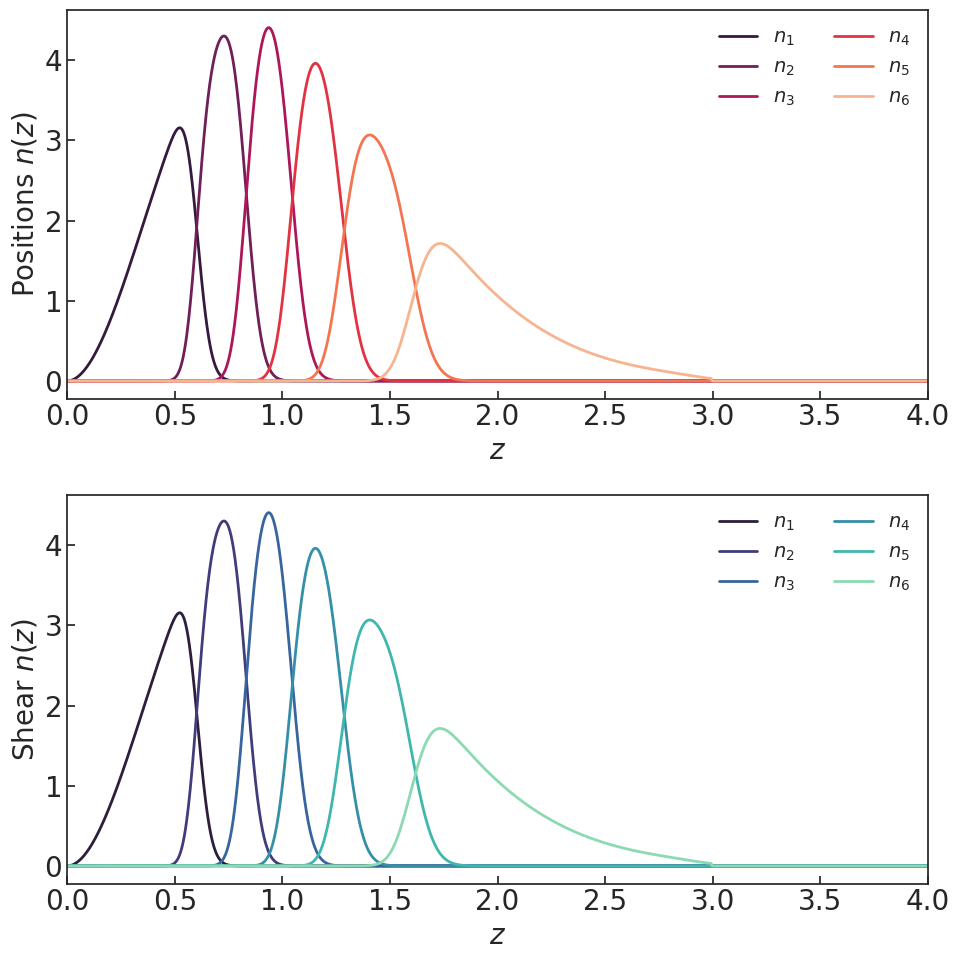

In [6]:

# Function to normalize dndz
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_example, z_nz)
dndz_she_norm = normalize_dndz(nz_example, z_nz)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values()))
    my_dndz_norm = np.zeros([len(nz_example), len(myz)])
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :])
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, zs)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, zs)

# Plotting dndz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
    axs[0].plot(z_nz, dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(dndz_she_norm)))):
    axs[1].plot(z_nz, dndz_she_norm[key], label=f'$n_{{{j+1}}}$', linewidth=2, color=color)

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 4)
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 4)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()



## Observables: shear and position tracers 

We compute tracers (window functions) for both shear and galaxy positions observations, to be later combined in the computation of the summary statistics.

In [7]:
# Select the perturbations object you want to use
perturbations = nonlinear_perturbations_emu
# Define the tracers
tracer_pos = PositionsTracer(perturbations=perturbations, 
                             dndz=my_dndz_pos_norm,
                             z = zs,
                             galaxy_bias_model='poly',
                             nuisance_params={'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0.0, 
                                              'b1_photo_poly2': 0.0, 'b1_photo_poly3': 0.0,
                                              'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                                              'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                                              'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
                                              'dz_pos_1': 0.0001, 'dz_pos_2': 0.0001,
                                              'dz_pos_3': 0.0001, 'dz_pos_4': 0.0001,
                                              'dz_pos_5': 0.0001, 'dz_pos_6': 0.0001})

tracer_she = ShearTracer(perturbations=perturbations, 
                             dndz=my_dndz_she_norm,
                             z = zs,
                             nuisance_params={'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41,
                                              'multiplicative_bias_1': 0.001, 'multiplicative_bias_2': 0.001,
                                              'multiplicative_bias_3': 0.001, 'multiplicative_bias_4': 0.001,
                                              'multiplicative_bias_5': 0.001, 'multiplicative_bias_6': 0.001,
                                              'dz_shear_1': 0.0001, 'dz_shear_2': 0.0001,
                                              'dz_shear_3': 0.0001, 'dz_shear_4': 0.0001,
                                              'dz_shear_5': 0.0001, 'dz_shear_6': 0.0001})

### Time profiling the $C_\ell$ function.

We compute angular power spectra, initialising the corresponding `cloelib` class. We show how to enable and disable the time profiling, and we run the `get_Cl()` function with and without it. 

`cloelib` implements a tool to benchmark time performances by using the [`pyinstrument`](https://pyinstrument.readthedocs.io/en/latest/) module. It is natively implemented in some functions and can be activated and deactivated with the `enable_profiling` and `disable_profiling` functions of  `cloelib`. It provides a detailed report of the function calls in HTML format.

The code will warn you when the profiling is enabled and disabled. 
When a function runs with profiling enabled, it shows in the standard output the name of the profiled function, the sampling interval and the report filename. 
The `set_output` function defines the output directory. The report file's name is composed of the module and function names, along with a timestamp in the format: module_function_YYYYMMDD_hhmmss.html.

Note that the profiling will cause overhead, i.e. the code will be slower with the profiling enabled.

Currently, the `cloelib` functions for which the time profiling option is implemented are: `get_Cl()` from the `summary_statistics.angular_two_point` module.

In [8]:
#profiling import
from cloelib.profiling import enable_profiling, disable_profiling 

nl = 100

ells = np.logspace(1., np.log10(3000), nl)

# Initialize the class
twopoint_pospos = AngularTwoPoint(tracer_pos, tracer_pos)
twopoint_shepos = AngularTwoPoint(tracer_she, tracer_pos)
twopoint_posshe = AngularTwoPoint(tracer_pos, tracer_she)
twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)

# Enable the profiling and computing the Cl
enable_profiling()

cells_GG = twopoint_pospos.get_Cl(ells, 0, perturbations.k)


# Disable the profiling
disable_profiling()

# Run the function without profiling.
cells_GGL = twopoint_shepos.get_Cl(ells, 0, perturbations.k)


Profiling: Enabled.
Profiling: Start profiling for cloelib.summary_statistics.angular_two_point.get_Cl
Profiling: Sampling Interval 0.001 s 
Profiling: Data saved in profiling_results/cloelib_summary_statistics_angular_two_point_get_Cl_20250828_151154.html
Profiling: Disabled.


### How to read the report

The profiling report is saved in the HTML file whose relative path is provided in the output. Opening the file, you access two tabs.

In the first one, the **call stack**, a tree graph shows all the called functions in a hierarchical way. 
In this representation, functions called by other functions appear at higher "branches", at a deeper indentation level.
Each line displays the total running time of the function, its file path, and the line where it is defined. 

In the second tab, dubbed **Timeline**, a reversed flame graph shows the called functions as blocks of variable lengths placed at different levels. The call hierarchy is ordered from top to bottom: the main function is at the top, and each function block is stacked below the one that called it. The length of each block is proportional to the running time. The graph can be zoomed in, and moving the mouse over a block reveals more details about the function call (like running time and the file location).

### Additional profiling options 
We show how to change the directory where the reports are stored and the sampling interval of the profiler.

The sampling interval, defined in seconds, sets the frequency at which the profiling "looks" at the run. A shorter sampling interval causes more overhead.
(For more details, look at the pyinstrument documentation [here](https://pyinstrument.readthedocs.io/en/latest/) ). 



In [9]:
#profiling setting import
from cloelib.profiling import set_interval, set_output

# Enable the profiling
enable_profiling()

# Change the output directory for the profiling reports
set_output("profiling_results_1")

# Set the sampling interval (in seconds)
set_interval(0.01)

# compute Cl
cells_EE = twopoint_sheshe.get_Cl(ells, 0, perturbations.k)

# Reset to the default values and disable the profiling 
set_output("profiling_results")
set_interval(0.001)
disable_profiling()

Profiling: Enabled.
Profiling: Start profiling for cloelib.summary_statistics.angular_two_point.get_Cl
Profiling: Sampling Interval 0.01 s 
Profiling: Data saved in profiling_results_1/cloelib_summary_statistics_angular_two_point_get_Cl_20250828_151157.html
Profiling: Disabled.


### Time profiling a generic function

**WARNING**: the profiling of undecorated function is untested.

The previous example show how to profile a function when the profiling option has been implemented natively.
However, the profiling wrapper `profile_function` can be applied to *any* function. 

In the next block we show how to apply it to the `get_xi()` function that compute the correlation function from the $C_\ell$ (see photo.ipynb for a tutorial).  

In [10]:
#import the profiling wrapper
from cloelib.profiling import  profile_function 

# Define at which angular separation to evaluate the correlation function
theta_rad = np.deg2rad(np.geomspace(5, 100, 20)/60)  
ells_integration = np.arange(2, 60000)

# Initialize correlation function calculation object
correlation_function_GG = AngularCorrelationFunctionWigner(twopoint_pospos, ells_integration, perturbations.k)

#apply the wrapper
get_xi_profiled = profile_function(correlation_function_GG.get_xi)

# Enable the profiling
enable_profiling()

xi_pospos = get_xi_profiled(theta_rad)

# Disable the profiling
disable_profiling()


Profiling: Enabled.
Profiling: Start profiling for cloelib.summary_statistics.angular_correlation_function_wigner.get_xi
Profiling: Sampling Interval 0.001 s 


Profiling: Data saved in profiling_results/cloelib_summary_statistics_angular_correlation_function_wigner_get_xi_20250828_151254.html
Profiling: Disabled.


### Note on nested functions

Notice that `get_xi()` calls `get_Cl()`. Thus, by calling the standard, unwrapped `get_xi()` with the profiling option enabled, one would profile only the `get_Cl()` function.
In case of functions recursively calling other profiled functions, when the main function is neither decorated nor wrapped with the profiling option, each call will be reported separately. To avoid this behaviour, apply the wrapper to the main function, and it will automatically disable the profiling of the nested ones, including them in the main report.
